In [1]:
# pip install xgboost
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install tabpfn xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 130.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 66.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-c

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
train_df = pd.read_csv(r'/content/drive/MyDrive/Shell_AI_Hackathon/train.csv')
test_df = pd.read_csv(r'/content/drive/MyDrive/Shell_AI_Hackathon/test.csv')

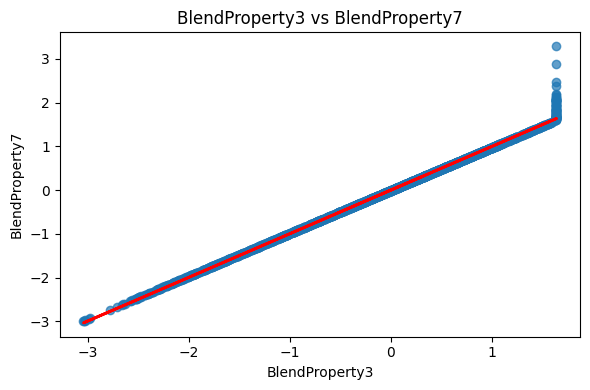

Correlation of each feature with BlendProperty3:

                      corr_with_3
BlendProperty7           0.997246
Component1_Property7     0.183102
Component2_Property7     0.164078
Component3_Property7     0.131208
Component4_Property7     0.114652
Component5_Property3     0.050131
Component5_Property7     0.016436
Component2_Property3    -0.000625
Component3_Property3    -0.011775
Component4_Property3    -0.019314
Component1_Property3    -0.034780


Correlation of each feature with BlendProperty7:

                      corr_with_7
BlendProperty3           0.997246
Component1_Property7     0.190750
Component2_Property7     0.161476
Component3_Property7     0.139810
Component4_Property7     0.122415
Component5_Property3     0.052184
Component5_Property7     0.015468
Component2_Property3    -0.002051
Component3_Property3    -0.014066
Component4_Property3    -0.019936
Component1_Property3    -0.036286


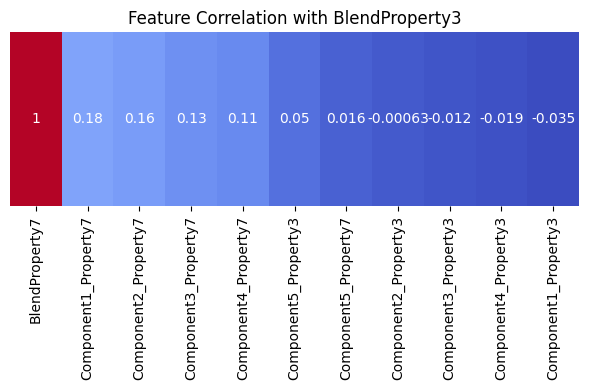

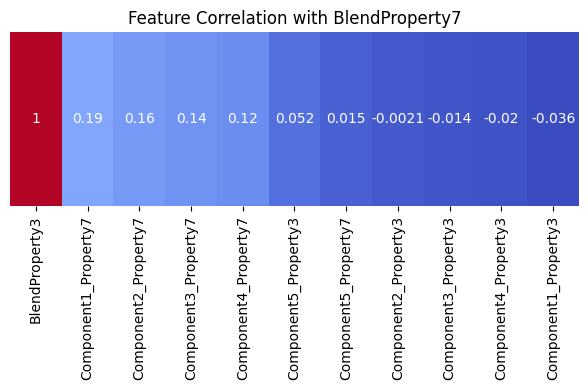

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns  # for nicer heatmap labels

# 1) Load your data
# df = pd.read_csv('your_blend_data.csv')
df = train_df
# 2) Scatter + best‐fit line for BlendProperty3 vs BlendProperty7
x = df['BlendProperty3'].values.reshape(-1, 1)
y = df['BlendProperty7'].values
lr = LinearRegression().fit(x, y)
y_pred = lr.predict(x)

plt.figure(figsize=(6,4))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, y_pred, color='red', linewidth=2)
plt.xlabel('BlendProperty3')
plt.ylabel('BlendProperty7')
plt.title('BlendProperty3 vs BlendProperty7')
plt.tight_layout()
plt.show()

# 3) Build the new DataFrame
prop3_cols = [f'Component{i}_Property3' for i in range(1, 6)]
prop7_cols = [f'Component{i}_Property7' for i in range(1, 6)]
new_df = df[prop3_cols + prop7_cols + ['BlendProperty3', 'BlendProperty7']].copy()

# 4) Compute full correlation matrix
full_corr = new_df.corr()

# 5) Extract correlations with each target
corr_with_3 = full_corr['BlendProperty3'].drop('BlendProperty3').sort_values(ascending=False)
corr_with_7 = full_corr['BlendProperty7'].drop('BlendProperty7').sort_values(ascending=False)

# 6) Print the correlation coefficients
print("Correlation of each feature with BlendProperty3:\n")
print(corr_with_3.to_frame('corr_with_3'))
print("\n\nCorrelation of each feature with BlendProperty7:\n")
print(corr_with_7.to_frame('corr_with_7'))

# 7) Plot heatmaps
plt.figure(figsize=(6, 4))
sns.heatmap(corr_with_3.to_frame().T, annot=True, cmap='coolwarm', cbar=False)
plt.title('Feature Correlation with BlendProperty3')
plt.yticks([])
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_with_7.to_frame().T, annot=True, cmap='coolwarm', cbar=False)
plt.title('Feature Correlation with BlendProperty7')
plt.yticks([])
plt.tight_layout()
plt.show()


In [ ]:
# import numpy as np
# import pandas as pd
# from scipy.linalg import qr

# def create_blend_features(df, frac_prefix="Component", prop_prefix="Component", n_components=5, n_props=10, eps=1e-9):
#     """
#     Adds 15 new features to the DataFrame:
#       - 10 weighted-average blend properties
#       - 5 CLR-transformed fraction features

#     Parameters:
#       df           - pandas DataFrame containing the original data
#       frac_prefix  - prefix for fraction columns
#       prop_prefix  - prefix for property columns
#       n_components - number of components in each blend
#       n_props      - number of properties per component
#       eps          - small constant to avoid log(0)

#     Returns:
#       df_new       - copy of the original df with 15 new columns added
#       new_cols     - list of the 15 added column names
#     """
#     df_new = df.copy()

#     # 1. Identify fraction and property columns
#     frac_cols = [f"{frac_prefix}{i}_fraction" for i in range(1, n_components+1)]
#     prop_cols = {
#         j: [f"{prop_prefix}{i}_Property{j}" for i in range(1, n_components+1)]
#         for j in range(1, n_props+1)
#     }

#     # 2. Clamp fractions to avoid log(0), normalize to sum=1
#     F = df_new[frac_cols].clip(lower=eps)
#     F = F.div(F.sum(axis=1), axis=0)

#     # 3. CLR transform
#     log_F = np.log(F.values)
#     geo_mean = np.exp(log_F.mean(axis=1, keepdims=True))
#     clr_vals = np.log(F.values / geo_mean)
#     clr_cols = [f"CLR_frac{i}" for i in range(1, n_components+1)]
#     clr_df = pd.DataFrame(clr_vals, columns=clr_cols, index=df_new.index)

#     # 4. Weighted-average blend properties
#     blend_cols = []
#     for j in range(1, n_props+1):
#         wavg_name = f"Blend_wtd_avg_Property{j}"
#         df_new[wavg_name] = (F.values * df_new[prop_cols[j]].values).sum(axis=1)
#         blend_cols.append(wavg_name)

#     # 5. Merge CLR columns
#     df_new = pd.concat([df_new, clr_df], axis=1)

#     # 6. Collect new column names
#     new_cols = blend_cols + clr_cols

#     return df_new, new_cols


# df_transformed, added_columns = create_blend_features(train_df)
# print("New features added:")
# print(added_columns)
# print(len(added_columns))


In [ ]:
# # train_df.append(df_transformed, ignore_index=True)
# df = pd.concat([train_df, df_transformed[added_columns]], axis=1)
# print(len(df.columns))
# df.head()

In [ ]:
train_df.shape

(2000, 65)

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
train_df = pd.read_csv(r'/content/drive/MyDrive/Shell_AI_Hackathon/train.csv')
test_df = pd.read_csv(r'/content/drive/MyDrive/Shell_AI_Hackathon/test.csv')

In [5]:
train_df.columns

Index(['Component1_fraction', 'Component2_fraction', 'Component3_fraction',
       'Component4_fraction', 'Component5_fraction', 'Component1_Property1',
       'Component2_Property1', 'Component3_Property1', 'Component4_Property1',
       'Component5_Property1', 'Component1_Property2', 'Component2_Property2',
       'Component3_Property2', 'Component4_Property2', 'Component5_Property2',
       'Component1_Property3', 'Component2_Property3', 'Component3_Property3',
       'Component4_Property3', 'Component5_Property3', 'Component1_Property4',
       'Component2_Property4', 'Component3_Property4', 'Component4_Property4',
       'Component5_Property4', 'Component1_Property5', 'Component2_Property5',
       'Component3_Property5', 'Component4_Property5', 'Component5_Property5',
       'Component1_Property6', 'Component2_Property6', 'Component3_Property6',
       'Component4_Property6', 'Component5_Property6', 'Component1_Property7',
       'Component2_Property7', 'Component3_Property7', 'C

In [ ]:
# import pandas as pd

# df = train_df
# # ── 1) define the names of your blend targets and drop them off for later
# blend_cols = [f'BlendProperty{i}' for i in range(1, 11)]
# blend_df  = df[blend_cols]                   # detach targets
# df_feats  = df.drop(columns=blend_cols)      # keep only fractions + raw comp‑properties

# # ── 2) loop over each property index
# for i in range(1, 11):
#     weighted_col_names = []

#     # 2a) compute & attach each weighted component‑property
#     for j in range(1, 6):
#         frac_col = f'Component{j}_fraction'
#         prop_col = f'Component{j}_Property{i}'
#         wname    = f'Weighted_Component{j}_Property{i}'

#         df_feats[wname] = df_feats[frac_col] * df_feats[prop_col]
#         weighted_col_names.append(wname)

#     # 2b) build the property‐i DataFrame and save it
#     prop_df = df_feats[weighted_col_names].copy()
#     prop_df[f'BlendProperty{i}'] = blend_df[f'BlendProperty{i}']

#     # give it a variable name you can pull later
#     globals()[f'property{i}_df'] = prop_df

#     # write to CSV
#     prop_df.to_csv(f'property{i}_df.csv', index=False)

# # ── After running this, you'll have:
# #    property1_df, property2_df, … property10_df  in memory,
# #    and  property1_df.csv … property10_df.csv  on disk.


In [ ]:
import pandas as pd
df = train_df

# 1) Pull out all blend targets up front
blend_cols = [f'BlendProperty{i}' for i in range(1, 11)]
blend_df  = df[blend_cols]       # just the 10 target columns
df_all    = df.drop(columns=blend_cols)  # the rest: fractions + raw comp‐props

# 2) For each property index 1…10, build the requested DF
for i in range(1, 11):
    # a) fraction cols
    frac_cols = [f'Component{j}_fraction' for j in range(1, 6)]

    # b) this property’s component columns
    prop_cols = [f'Component{j}_Property{i}' for j in range(1, 6)]

    # c) slice them out and then append the blend target
    prop_df = df_all[frac_cols + prop_cols].copy()
    prop_df[f'BlendProperty{i}'] = blend_df[f'BlendProperty{i}']

    # d) assign to a variable and write to CSV
    globals()[f'property{i}_df'] = prop_df
    prop_df.to_csv(f'property{i}_df.csv', index=False)

# Now you have in memory: property1_df … property10_df,
# and on disk: property1_df.csv … property10_df.csv


In [ ]:
property1_df.head()


,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,BlendProperty1
0,0.21,0.00,0.42,0.25,0.12,-0.021782,1.981251,0.020036,0.140315,1.032029,0.489143
1,0.02,0.33,0.19,0.46,0.00,-0.224339,1.148036,-1.107840,0.149533,-0.354000,-1.257481
2,0.08,0.08,0.18,0.50,0.16,0.457763,0.242591,-0.922492,0.908213,0.972003,1.784349
3,0.25,0.42,0.00,0.07,0.26,-0.577734,-0.930826,0.815284,0.447514,0.455717,-0.066422
4,0.26,0.16,0.08,0.50,0.00,0.120415,0.666268,-0.626934,2.725357,0.392259,-0.118913


In [ ]:
# !pip install statsmodels pygam


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso # Corrected import
from sklearn.metrics import mean_absolute_percentage_error, r2_score
import statsmodels.api as sm
# from statsmodels.gam.generalized_additive_model import GLMGam # Removed GLMGam import
# from statsmodels.gam.smooth_basis import BSplines # Removed BSplines import
import numpy as np
# import patsy # Removed patsy import

# 1. Load the dataframe (e.g., property3_df.csv)
# df = pd.read_csv('property3_df.csv')
df3 = property3_df # Changed from property1_df to property3_df

# 2. Separate features and target
X = df3.drop(columns='BlendProperty3').values
y = df3['BlendProperty3'].values

# 3. Polynomial transformation (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
print(X_poly.shape)
# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# 5. Initialize models
models = {
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=0.1, max_iter=10000)
}
results = {}

# 6a. Fit and evaluate LinearRegression & Lasso
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'R2':   r2_score(y_test, y_pred)
    }

# 6b. Fit and evaluate GLM (Gaussian identity)
glm = sm.GLM(y_train, sm.add_constant(X_train), family=sm.families.Gaussian())
glm_res = glm.fit()
glm_pred = glm_res.predict(sm.add_constant(X_test))
results['GLM_Gaussian'] = {
    'MAPE': mean_absolute_percentage_error(y_test, glm_pred),
    'R2':   r2_score(y_test, glm_pred)
}

# 6c. Fit and evaluate GAM (Gaussian identity splines)
# Removed GAM evaluation due to extrapolation issues with BSplines

# 7. Print out all metrics
for model_name, metrics in results.items():
    print(f"=== {model_name} ===")
    print(f"MAPE: {metrics['MAPE']:.4f}")
    print(f"R2:   {metrics['R2']:.4f}\n")

(2000, 65)
=== LinearRegression ===
MAPE: 2.4870
R2:   0.7604

=== Lasso ===
MAPE: 1.2997
R2:   0.3275

=== GLM_Gaussian ===
MAPE: 2.4870
R2:   0.7604



In [ ]:
k = np.array([1,2,3])
k.shape

(3,)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score

import xgboost as xgb
from catboost import CatBoostRegressor

# ——————————————————————————
# 1) load your data
# df3 = pd.read_csv('property5_df.csv')    # or use your in‑memory df
df3 = property9_df                        # as you already had

# 2) split out X and y
X = df3.drop(columns='BlendProperty9').values
y = df3['BlendProperty9'].values

# 3) polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# 4) train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# 5) define all models
models = {
    'LinearRegression':         LinearRegression(),
    'Lasso':                    Lasso(alpha=0.1, max_iter=10_000),
    'ElasticNet':               ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10_000),
    'SVR (RBF kernel)':         SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'RandomForest':             RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting':         GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost':                  xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'CatBoost':                 CatBoostRegressor(iterations=200, learning_rate=0.1, silent=True, random_seed=42)
}

# 6) train, predict & evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'R2':   r2_score(y_test, y_pred)
    }

# 7) print out metrics
for model_name, metrics in results.items():
    print(f"=== {model_name} ===")
    print(f"  MAPE: {metrics['MAPE']:.4f}")
    print(f"   R² : {metrics['R2']:.4f}\n")


=== LinearRegression ===
  MAPE: 2.0453
   R² : 0.8098

=== Lasso ===
  MAPE: 2.2642
   R² : 0.1585

=== ElasticNet ===
  MAPE: 2.5341
   R² : 0.1853

=== SVR (RBF kernel) ===
  MAPE: 2.6446
   R² : 0.4483

=== RandomForest ===
  MAPE: 2.1753
   R² : 0.7580

=== GradientBoosting ===
  MAPE: 2.0986
   R² : 0.7867

=== XGBoost ===
  MAPE: 2.1222
   R² : 0.7672

=== CatBoost ===
  MAPE: 2.0424
   R² : 0.7882



In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score

# try to import TabPFNRegressor
try:
    from tabpfn import TabPFNRegressor
    has_tabpfn = True
except ImportError:
    has_tabpfn = False

from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

import xgboost as xgb
from catboost import CatBoostRegressor

# ——————————————————————————
# 1) load your data
df3 = property3_df                        # or pd.read_csv('property9_df.csv')

# 2) split out X and y
X = df3.drop(columns='BlendProperty3').values
y = df3['BlendProperty3'].values

# 3) polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# 4) train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# 5) define all models, including TabPFN if available
models = {
    'LinearRegression':         LinearRegression(),
    'Lasso':                    Lasso(alpha=0.1, max_iter=10_000),
    'ElasticNet':               ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10_000),
    'SVR (RBF kernel)':         SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'RandomForest':             RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting':         GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost':                  xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'CatBoost':                 CatBoostRegressor(iterations=200, learning_rate=0.1, silent=True, random_seed=42),
    # fallback regressors if TabPFN is missing
    'KNeighbors':               KNeighborsRegressor(n_neighbors=5),
    'MLPRegressor':             MLPRegressor(hidden_layer_sizes=(100,), max_iter=1_000, random_state=42),
}

# insert TabPFN as the next model if it’s installed
if has_tabpfn:
    # you can tweak `thompson_sampling` or `predict_proba` flags as needed
    models['TabPFN'] = TabPFNRegressor()

# 6) train, predict & evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'R2':   r2_score(y_test, y_pred)
    }

# 7) print out metrics
for model_name, metrics in results.items():
    print(f"=== {model_name} ===")
    print(f"  MAPE: {metrics['MAPE']:.4f}")
    print(f"   R² : {metrics['R2']:.4f}\n")


=== LinearRegression ===
  MAPE: 2.4870
   R² : 0.7604

=== Lasso ===
  MAPE: 1.2997
   R² : 0.3275

=== ElasticNet ===
  MAPE: 1.1687
   R² : 0.2920

=== SVR (RBF kernel) ===
  MAPE: 1.7193
   R² : 0.5246

=== RandomForest ===
  MAPE: 2.2927
   R² : 0.7648

=== GradientBoosting ===
  MAPE: 2.4350
   R² : 0.7602

=== XGBoost ===
  MAPE: 2.1441
   R² : 0.7580

=== CatBoost ===
  MAPE: 2.3511
   R² : 0.7598

=== KNeighbors ===
  MAPE: 2.2377
   R² : 0.0159

=== MLPRegressor ===
  MAPE: 2.4193
   R² : 0.5953

=== TabPFN ===
  MAPE: 2.4565
   R² : 0.7774



In [ ]:
# ——————————————————————————
# 8) Identify best model (highest R²)
best_name  = max(results, key=lambda k: results[k]['R2'])
best_model = models[best_name]
print(f"\n>> Using best model for diagnostics: {best_name}\n")

# 9) Permutation Importance
from sklearn.inspection import permutation_importance

# create DataFrame wrapper so we have column names
feat_cols = [f"feat_{i}" for i in range(X_test.shape[1])]
X_test_df = pd.DataFrame(X_test, columns=feat_cols)

# Use RandomForestRegressor for feature importance as TabPFN doesn't support it directly
# You can choose another tree-based model or LinearRegression if preferred
importance_model = RandomForestRegressor(n_estimators=100, random_state=42)
importance_model.fit(X_train, y_train)


perm = permutation_importance(
    importance_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring="r2"
)
perm_series = pd.Series(perm.importances_mean, index=feat_cols)
print("=== Permutation Importance (mean R² drop) ===")
print(perm_series.sort_values(ascending=False).head(30))

# 10) Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use the TRAIN set for VIF (to avoid leakage)
X_train_df = pd.DataFrame(X_train, columns=feat_cols)
vif_data = pd.DataFrame({
    "feature": feat_cols,
    "VIF": [
        variance_inflation_factor(X_train_df.values, i)
        for i in range(len(feat_cols))
    ]
})
print("\n=== Top 10 VIF ===")
print(vif_data.sort_values("VIF", ascending=False).head(10))

# 11) Recursive Feature Elimination (RFE)
from sklearn.feature_selection import RFE

# Use RandomForestRegressor for RFE as TabPFN doesn't support it directly
rfe_model = RandomForestRegressor(n_estimators=100, random_state=42)

# here we ask RFE to keep the top 10 features
selector = RFE(estimator=rfe_model, n_features_to_select=10, step=1)
selector.fit(X_train, y_train)

selected_feats = [f for f, keep in zip(feat_cols, selector.support_) if keep]
print("\n=== RFE: Top 10 Selected Features ===")
print(selected_feats)


>> Using best model for diagnostics: TabPFN

=== Permutation Importance (mean R² drop) ===
feat_1     0.313639
feat_20    0.302370
feat_11    0.193034
feat_10    0.008696
feat_38    0.005184
feat_0     0.005074
feat_31    0.003356
feat_63    0.001655
feat_48    0.001594
feat_62    0.001166
feat_23    0.001161
feat_21    0.001063
feat_32    0.001013
feat_45    0.000681
feat_30    0.000622
feat_24    0.000561
feat_49    0.000560
feat_7     0.000551
feat_33    0.000498
feat_6     0.000454
feat_22    0.000452
feat_41    0.000425
feat_36    0.000386
feat_12    0.000373
feat_18    0.000359
feat_29    0.000341
feat_37    0.000313
feat_9     0.000278
feat_2     0.000247
feat_60    0.000235
dtype: float64

=== Top 10 VIF ===
  feature  VIF
0  feat_0  inf
1  feat_1  inf
2  feat_2  inf
3  feat_3  inf
4  feat_4  inf
5  feat_5  inf
6  feat_6  inf
7  feat_7  inf
8  feat_8  inf
9  feat_9  inf


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

def plot_histogram_grid(df, page=1, plots_per_page=15, grid_cols=5):
    """
    Generates and displays a grid of histograms for a given page of columns in a DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame.
        page (int): The page number to display (1-indexed).
        plots_per_page (int): The number of plots to show on one page.
        grid_cols (int): The number of columns in the plot grid.
    """
    # --- 1. Validate Inputs and Calculate Page Range ---
    if not isinstance(df, pd.DataFrame):
        raise ValueError("Input 'df' must be a pandas DataFrame.")
    if df.empty:
        print("The DataFrame is empty. Nothing to plot.")
        return

    num_columns = df.shape[1]
    start_col = (page - 1) * plots_per_page
    end_col = start_col + plots_per_page

    if start_col >= num_columns:
        print(f"Page {page} is out of bounds. The DataFrame has only {num_columns} columns.")
        return

    # Select the columns for the current page
    columns_to_plot = df.columns[start_col:end_col]

    if len(columns_to_plot) == 0:
        print("No columns to plot for the selected page.")
        return

    # --- 2. Set up the Grid Layout ---
    num_plots = len(columns_to_plot)
    grid_rows = math.ceil(num_plots / grid_cols)

    # --- 3. Create the Plot ---
    # Set a visually appealing style from seaborn
    sns.set_style("whitegrid")

    # Create the figure and axes grid. Adjust figsize for readability.
    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(18, 4 * grid_rows))

    # Flatten the axes array for easy iteration, regardless of grid dimensions
    axes = axes.flatten()

    # --- 4. Generate Each Histogram ---
    for i, col_name in enumerate(columns_to_plot):
        ax = axes[i]

        # Use seaborn for a nice-looking histogram
        # The `kde=True` adds a density curve for a smoother representation of the distribution
        sns.histplot(data=df, x=col_name, ax=ax, kde=True, color=sns.color_palette("viridis", num_plots)[i])

        # Set a clear and concise title for each subplot
        ax.set_title(f'Distribution of {col_name}', fontsize=12)
        ax.set_xlabel('') # Keep the x-axis clean
        ax.set_ylabel('Frequency', fontsize=10)
        ax.tick_params(axis='x', rotation=15) # Rotate x-ticks slightly if names are long

    # --- 5. Clean Up and Display ---
    # Hide any unused subplots if the last page is not full
    for i in range(num_plots, len(axes)):
        axes[i].set_visible(False)

    # Add a main title for the entire figure
    plt.suptitle(f'Histograms of Columns {start_col + 1} to {min(end_col, num_columns)}', fontsize=20, y=1.02)

    # Adjust layout to prevent titles and labels from overlapping
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    # Display the plot
    plt.show()


# --- Main Execution Block ---
if __name__ == '__main__':

    num_rows = 1000
    num_features = 40
    feature_names = [f'Parameter_{i+1}' for i in range(num_features)]

    # Display the first 15 columns (Page 1)
    print("Displaying the first page of histograms (columns 1-15)...")
    plot_histogram_grid(property3_df, page=1, plots_per_page=15, grid_cols=5)


In [ ]:
from sklearn.preprocessing     import PolynomialFeatures
from sklearn.inspection        import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score

# Assuming X, y are already defined from your data loading steps
# Assuming models, results are already defined from your model training steps
# Assuming importance_model is already defined and fitted from cell WjwQGuWTsy1R

# ——————————————————————————
# 3) Polynomial expansion (degree=2)
poly     = PolynomialFeatures(degree=2, include_bias=False)
X_poly   = poly.fit_transform(X)
# Assuming df3 is available with the original feature names before polynomial expansion
raw_cols = df3.drop(columns=[col for col in df3.columns if 'BlendProperty' in col]).columns
feat_names = poly.get_feature_names_out(raw_cols)

# 4) Train/test split (on the expanded features)
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# 5) Pick your best model from `results`
best_name  = max(results, key=lambda k: results[k]['R2'])
best_model = models[best_name]
print(f"🔎 Best model identified from previous run: `{best_name}`\n")

# 6) Permutation importance on the test set using the importance_model
# Explicitly use the importance_model (RandomForestRegressor) which supports this.
# Ensure importance_model is defined and fitted in a previous cell (WjwQGuWTsy1R).
if 'importance_model' not in globals():
    print("Warning: importance_model not found. Please run cell WjwQGuWTsy1R first.")
    # Fallback: Fit a temporary importance model if not already available
    from sklearn.ensemble import RandomForestRegressor
    importance_model = RandomForestRegressor(n_estimators=100, random_state=42)
    # Need to fit it on the polynomial features if fitting here
    temp_X_train, _, temp_y_train, _ = train_test_split(
        X_poly, y, test_size=0.2, random_state=42
    )
    importance_model.fit(temp_X_train, temp_y_train)


perm = permutation_importance(
    importance_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring='r2'
)

# auto‑keep = all features whose importance ≥ 0
auto_keep   = {n for n, imp in zip(feat_names, perm.importances_mean) if imp >= 0}

# manually override if you like:
manual_keep = set([
                    'feat_10', # Based on observation from WjwQGuWTsy1R output
                    'feat_14', # Based on observation from WjwQGuWTsy1R output
                    'feat_17', # Based on observation from WjwQGuWTsy1R output
                    'feat_5',  # Based on observation from WjwQGuWTsy1R output
                    'feat_2',  # Based on observation from WjwQGuWTsy1R output
                    'feat_15', # Based on observation from WjwQGuWTsy1R output
                    'feat_12', # Based on observation from WjwQGuWTsy1R output
                    ])
manual_drop = set([
    # e.g. 'x2 x3', ...
])

keep_names = list((auto_keep | manual_keep) - manual_drop)
keep_idx   = [i for i, n in enumerate(feat_names) if n in keep_names]

print(f"Selected {len(keep_idx)} / {len(feat_names)} features after filtering.\n")

# 7) Rebuild reduced train/test
X_train_sel = X_train[:, keep_idx]
X_test_sel  = X_test[:, keep_idx]

# 8) Retrain & re-evaluate all models on the reduced set
results_sel = {}
for name, model in models.items():
    print(f"Retraining {name} on selected features...")
    # re-fit on selected features
    # Need to create a new instance for TabPFN as it might have internal state
    if name == 'TabPFN':
         model_to_fit = TabPFNRegressor(ignore_pretraining_limits=True)
    else:
         model_to_fit = model


    model_to_fit.fit(X_train_sel, y_train)
    y_pred = model_to_fit.predict(X_test_sel)
    results_sel[name] = {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'R2'  : r2_score(y_test, y_pred)
    }

# 9) Print new metrics
print("\n=== Metrics after permutation‑based feature filtering ===")
for m, mets in results_sel.items():
    print(f"--- {m} ---  MAPE: {mets['MAPE']:.4f},  R²: {mets['R2']:.4f}")

🔎 Best model identified from previous run: `TabPFN`

Selected 7 / 20 features after filtering.

Retraining LinearRegression on selected features...
Retraining Lasso on selected features...
Retraining ElasticNet on selected features...
Retraining SVR (RBF kernel) on selected features...
Retraining RandomForest on selected features...
Retraining GradientBoosting on selected features...
Retraining XGBoost on selected features...
Retraining CatBoost on selected features...
Retraining KNeighbors on selected features...
Retraining MLPRegressor on selected features...
Retraining TabPFN on selected features...

=== Metrics after permutation‑based feature filtering ===
--- LinearRegression ---  MAPE: 1.8726,  R²: 0.2420
--- Lasso ---  MAPE: 1.0981,  R²: -0.0067
--- ElasticNet ---  MAPE: 1.0835,  R²: 0.0191
--- SVR (RBF kernel) ---  MAPE: 2.6062,  R²: 0.3814
--- RandomForest ---  MAPE: 2.7266,  R²: 0.4327
--- GradientBoosting ---  MAPE: 3.0239,  R²: 0.4491
--- XGBoost ---  MAPE: 2.7908,  R²: 0.4

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score

# Optional: try to import TabPFNRegressor
try:
    from tabpfn import TabPFNRegressor
    has_tabpfn = True
except ImportError:
    has_tabpfn = False

from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
from catboost import CatBoostRegressor

# ——————————————————————————
# 1) Load your data
df3 = property3_df  # Replace with your preferred propertyN_df

# 2) Separate features and target
X = df3.drop(columns='BlendProperty3').values
y = df3['BlendProperty3'].values

# 3) Train-test split (NO polynomial features here)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) Define models
models = {
    'LinearRegression':         LinearRegression(),
    'Lasso':                    Lasso(alpha=0.1, max_iter=10_000),
    'ElasticNet':               ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10_000),
    'SVR (RBF kernel)':         SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'RandomForest':             RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting':         GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost':                  xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'CatBoost':                 CatBoostRegressor(iterations=200, learning_rate=0.1, silent=True, random_seed=42),
    'KNeighbors':               KNeighborsRegressor(n_neighbors=5),
    'MLPRegressor':             MLPRegressor(hidden_layer_sizes=(100,), max_iter=1_000, random_state=42),
}

# 5) Optionally add TabPFN if available
if has_tabpfn:
    models['TabPFN'] = TabPFNRegressor()

# 6) Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'R2':   r2_score(y_test, y_pred)
    }

# 7) Print evaluation metrics
for model_name, metrics in results.items():
    print(f"=== {model_name} ===")
    print(f"  MAPE: {metrics['MAPE']:.4f}")
    print(f"   R² : {metrics['R2']:.4f}\n")


=== LinearRegression ===
  MAPE: 1.2198
   R² : 0.0072

=== Lasso ===
  MAPE: 1.0981
   R² : -0.0067

=== ElasticNet ===
  MAPE: 1.0981
   R² : -0.0067

=== SVR (RBF kernel) ===
  MAPE: 2.9289
   R² : 0.3949

=== RandomForest ===
  MAPE: 2.5714
   R² : 0.4025

=== GradientBoosting ===
  MAPE: 2.5994
   R² : 0.4277

=== XGBoost ===
  MAPE: 2.7810
   R² : 0.3632

=== CatBoost ===
  MAPE: 2.3583
   R² : 0.4470

=== KNeighbors ===
  MAPE: 3.5494
   R² : 0.2065

=== MLPRegressor ===
  MAPE: 2.4181
   R² : 0.4160

=== TabPFN ===
  MAPE: 2.6358
   R² : 0.4515



In [ ]:
from sklearn.preprocessing import SplineTransformer

df3 = property3_df  # Replace with your preferred propertyN_df

# 2) Separate features and target
X = df3.drop(columns='BlendProperty3').values
y = df3['BlendProperty3'].values

# ——————————————————————————
# 3) Replace your polynomial expansion with splines:
#    degree = spline degree (cubic = 3)
#    n_knots = number of knots (you can tune this)
spline = SplineTransformer(degree=3, n_knots=5, include_bias=False)
X_spline = spline.fit_transform(X)

# 4) train‑test split on the spline features
X_train, X_test, y_train, y_test = train_test_split(
    X_spline, y, test_size=0.2, random_state=42
)

# 5) (models definition stays exactly as before)
models = {
    'LinearRegression': LinearRegression(),
    'Lasso':            Lasso(alpha=0.1, max_iter=10_000),
    'ElasticNet':       ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10_000),
    'SVR (RBF)':        SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost':          xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'CatBoost':         CatBoostRegressor(iterations=200, learning_rate=0.1, silent=True, random_seed=42),
    'KNeighbors':       KNeighborsRegressor(n_neighbors=5),
    'MLPRegressor':     MLPRegressor(hidden_layer_sizes=(100,), max_iter=1_000, random_state=42),
}

if has_tabpfn:
    models['TabPFN'] = TabPFNRegressor()

# 6) Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'R2':   r2_score(y_test, y_pred)
    }

# 7) Print evaluation metrics
for model_name, metrics in results.items():
    print(f"=== {model_name} ===")
    print(f"  MAPE: {metrics['MAPE']:.4f}")
    print(f"   R² : {metrics['R2']:.4f}\n")



=== LinearRegression ===
  MAPE: 2.5976
   R² : 0.3877

=== Lasso ===
  MAPE: 1.0981
   R² : -0.0067

=== ElasticNet ===
  MAPE: 1.1216
   R² : 0.0551

=== SVR (RBF) ===
  MAPE: 2.8388
   R² : 0.4212

=== RandomForest ===
  MAPE: 2.6463
   R² : 0.4047

=== GradientBoosting ===
  MAPE: 2.6518
   R² : 0.4266

=== XGBoost ===
  MAPE: 2.7961
   R² : 0.3968

=== CatBoost ===
  MAPE: 2.6995
   R² : 0.4171

=== KNeighbors ===
  MAPE: 3.3851
   R² : 0.2094

=== MLPRegressor ===
  MAPE: 2.7064
   R² : 0.4159

=== TabPFN ===
  MAPE: 2.7979
   R² : 0.4575



# Without any Polynomial Expansion

In [ ]:
from sklearn.preprocessing import SplineTransformer

df3 = property9_df  # Replace with your preferred propertyN_df

# 2) Separate features and target
X = df3.drop(columns='BlendProperty9').values
y = df3['BlendProperty9'].values

from sklearn.kernel_ridge import KernelRidge


# 4) train-test split on raw X
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5) define models plus a KernelRidge entry:
models = {
    'LinearRegression':   LinearRegression(),
    'Lasso':              Lasso(alpha=0.1, max_iter=10_000),
    'ElasticNet':         ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10_000),
    'SVR (RBF)':          SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'RandomForest':       RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting':   GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost':            xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'CatBoost':           CatBoostRegressor(iterations=200, learning_rate=0.1, silent=True, random_seed=42),
    'KNeighbors':         KNeighborsRegressor(n_neighbors=5),
    'MLPRegressor':       MLPRegressor(hidden_layer_sizes=(100,), max_iter=1_000, random_state=42),
    'KernelRidge (RBF)':  KernelRidge(kernel='rbf', alpha=1.0, gamma=None)
}

if has_tabpfn:
    models['TabPFN'] = TabPFNRegressor()

# 6) fit & evaluate (exactly as before, using raw X_train/X_test)
#    … your existing for‑loop …


# 6) Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'R2':   r2_score(y_test, y_pred)
    }

# 7) Print evaluation metrics
for model_name, metrics in results.items():
    print(f"=== {model_name} ===")
    print(f"  MAPE: {metrics['MAPE']:.4f}")
    print(f"   R² : {metrics['R2']:.4f}\n")



=== LinearRegression ===
  MAPE: 3.8386
   R² : 0.2559

=== Lasso ===
  MAPE: 1.4943
   R² : 0.1198

=== ElasticNet ===
  MAPE: 1.6368
   R² : 0.1350

=== SVR (RBF) ===
  MAPE: 4.0040
   R² : 0.3776

=== RandomForest ===
  MAPE: 2.7787
   R² : 0.4412

=== GradientBoosting ===
  MAPE: 2.3657
   R² : 0.4793

=== XGBoost ===
  MAPE: 2.6091
   R² : 0.4609

=== CatBoost ===
  MAPE: 2.5464
   R² : 0.4768

=== KNeighbors ===
  MAPE: 4.0087
   R² : 0.3074

=== MLPRegressor ===
  MAPE: 3.1101
   R² : 0.4511

=== KernelRidge (RBF) ===
  MAPE: 4.1336
   R² : 0.2976

=== TabPFN ===
  MAPE: 1.9981
   R² : 0.4969



In [ ]:
numbers = [
    0.005348, 0.060780, 1.134, 0.087354, 0.0156,
    0.000587, 1.0263, 2.4867, 1.8343, 0.079608
]

total = sum(numbers)
print("Total sum:", total)


Total sum: 6.730576999999999


In [ ]:
!pip install catboost xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.0 MB/s eta 0:00:00


In [ ]:
components = ['Component1', 'Component2', 'Component3', 'Component4', 'Component5']
properties = [f'Property{i}' for i in range(1, 11)]


# Create Weighted Average Features
for prop in properties:
    train_df[f'Weighted_{prop}'] = sum(
        train_df[f'{comp}_fraction'] * train_df[f'{comp}_{prop}'] for comp in components
    )

    cols = [f'{comp}_{prop}' for comp in components]
    # Variance across the five component values for each property
    train_df[f'{prop}_variance'] = train_df[cols].var(axis=1)
    # Range across the five component values for each property
    train_df[f'{prop}_range']    = train_df[cols].max(axis=1) - train_df[cols].min(axis=1)


for prop in properties:
    test_df[f'Weighted_{prop}'] = sum(
        test_df[f'{comp}_fraction'] * test_df[f'{comp}_{prop}'] for comp in components
    )
    cols = [f'{comp}_{prop}' for comp in components]
    # Variance across the five component values for each property
    test_df[f'{prop}_variance'] = test_df[cols].var(axis=1)
    # Range across the five component values for each property
    test_df[f'{prop}_range']    = test_df[cols].max(axis=1) - test_df[cols].min(axis=1)

In [ ]:
train_df.shape

(2000, 95)

In [ ]:
def compute_entropy_of_fractions(df, fraction_cols):
    """
    Computes Shannon entropy of component fractions for each row.
    """
    def entropy(row):
        fractions = row[fraction_cols].values
        fractions = fractions[fractions > 0]  # avoid log(0)
        return -np.sum(fractions * np.log(fractions))

    df['fraction_entropy'] = df.apply(entropy, axis=1)
    return df

fraction_cols = ['Component1_fraction', 'Component2_fraction', 'Component3_fraction','Component4_fraction', 'Component5_fraction']
train_df = compute_entropy_of_fractions(train_df, fraction_cols)
test_df = compute_entropy_of_fractions(test_df, fraction_cols)



In [ ]:
train_df.shape

(2000, 96)

In [ ]:
type(X)

numpy.ndarray

In [ ]:
# from sklearn.ensemble import RandomForestRegressor
# import numpy as np

# # X: ndarray of shape (n_samples, n_features)
# # y: ndarray of shape (n_samples, 10)

# # 1) Fit multi-output Random Forest directly
# rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
# rf.fit(X, y)

# # 2) Get feature importances (aggregated across all 10 targets internally)
# importances = rf.feature_importances_

# # 3) Get indices of top 30 features
# top30_indices = np.argsort(importances)[::-1][:80]

# # 4) Subset the arrays
# X_top30 = X[:, top30_indices]


In [ ]:
# X_top30 = X[:, top30_indices]
# X_df = train_df.drop(columns=y.columns)
# X = X_df.values
X_df = train_df_transformed.drop(columns=target_cols)

# top30_feature_names = X_df.columns[top30_indices].tolist()

# sub = test_df_transformed[top30_feature_names].values

# top30_feature_names


['Component2_fraction',
 'Component5_fraction',
 'Component4_fraction',
 'Weighted_Property6',
 'Component1_fraction',
 'Component3_fraction',
 'Weighted_Property8',
 'Weighted_Property4',
 'Component4_Property9',
 'Component2_Property5',
 'Weighted_Property2',
 'Component2_Property7',
 'Weighted_Property9',
 'Weighted_Property7',
 'Weighted_Property1',
 'Component5_Property8',
 'fraction_entropy',
 'Component4_Property6',
 'Component1_Property7',
 'Component3_Property6',
 'Component4_Property8',
 'Component3_Property4',
 'Component4_Property2',
 'Component1_Property5',
 'Component3_Property7',
 'Component3_Property8',
 'Weighted_Property5',
 'Weighted_Property10',
 'Component3_Property1',
 'Component3_Property10',
 'Component1_Property4',
 'Component5_Property2',
 'Component1_Property8',
 'Component3_Property2',
 'Component2_Property6',
 'Component1_Property6',
 'Component4_Property5',
 'Component5_Property4',
 'Component4_Property1',
 'Component2_Property8',
 'Component5_Property6',


In [ ]:
type(X)

numpy.ndarray

In [ ]:
# import numpy as np
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.ensemble import RandomForestRegressor

# # --- 0) Assumptions: ---
# # X: ndarray, shape (n_samples, n_features)
# # y: ndarray, shape (n_samples, 10)

# # --- 1) Create 2nd‑degree polynomial features ---
# poly = PolynomialFeatures(degree=2, include_bias=False)
# X_poly = poly.fit_transform(X)
# # X_poly.shape == (n_samples, n_poly_features)
# # You can get feature names if needed:
# # poly_feature_names = poly.get_feature_names_out()

# # --- 2) Fit a multi‑output RandomForest on expanded features ---
# rf = RandomForestRegressor(
#     n_estimators=200,
#     max_depth=None,
#     random_state=42,
#     n_jobs=-1
# )
# rf.fit(X_poly, y)

# # --- 3) Get and sort feature importances ---
# importances = rf.feature_importances_  # shape (n_poly_features,)
# # argsort in descending order:
# idx_desc = np.argsort(importances)[::-1]




Original poly feature count: 3827
Selected top 80 feature count: 80
Example selected names: ['x1' 'x4' 'x1^2' 'x1 x3' 'x2 x4' 'x0 x1' 'x3 x4' 'x1 x4' 'x0 x4' 'x1 x70']


In [ ]:
# # --- 4) Pick top 80 features ---
# top80_idx = idx_desc[:100]

# # --- 5) Subset your expanded array and (optionally) names ---
# X_top80 = X_poly[:, top80_idx]

# # If you want the feature names for those top 80:
# poly_feature_names = poly.get_feature_names_out()
# top80_names = poly_feature_names[top80_idx]

# # --- Now X_top80 is your reduced-design matrix ---
# print("Original poly feature count:", X_poly.shape[1])
# print("Selected top 80 feature count:", X_top80.shape[1])
# print("Example selected names:", top80_names[:10])

Original poly feature count: 3827
Selected top 80 feature count: 100
Example selected names: ['x1' 'x4' 'x1^2' 'x1 x3' 'x2 x4' 'x0 x1' 'x3 x4' 'x1 x4' 'x0 x4' 'x1 x70']


In [ ]:
# # Apply the polynomial transformation to the test data
# sub_poly = poly.transform(sub)

# # Select the top 80 features from the transformed test data
# sub = sub_poly[:, top80_idx]

# # If you want the feature names for those top 80 (optional)
# poly_feature_names = poly.get_feature_names_out()
# top80_feature_names = poly_feature_names[top80_idx].tolist()

# print("Shape of the reduced test data:", sub.shape)
# print("Example selected names:", top80_feature_names[:10])

Shape of the reduced test data: (500, 100)
Example selected names: ['x1', 'x4', 'x1^2', 'x1 x3', 'x2 x4', 'x0 x1', 'x3 x4', 'x1 x4', 'x0 x4', 'x1 x70']


In [ ]:
import pandas as pd
import numpy as np

def add_row_statistics(
    df: pd.DataFrame,
    cols: list = None,
    prefix: str = 'row',
    stats: list = None,
    skipna: bool = True
) -> pd.DataFrame:
    """
    Add row-level statistical features to a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    cols : list, optional
        List of columns to include; if None, all numeric columns are used.
    prefix : str
        Prefix for new feature column names.
    stats : list, optional
        List of statistics to compute. Options include:
            'mean', 'std', 'var', 'mad', 'skew', 'kurt', 'range', 'iqr'
        If None, defaults to ['mean', 'std', 'var', 'mad', 'range', 'iqr'].
    skipna : bool
        Whether to skip NA values when computing statistics.

    Returns
    -------
    pd.DataFrame
        DataFrame with new statistical feature columns added.
    """
    # Copy to avoid modifying original
    df_out = df.copy()

    # Select columns
    if cols is None:
        cols = df_out.select_dtypes(include=[np.number]).columns.tolist()
    if not cols:
        raise ValueError("No numeric columns found for row statistics.")

    # Define default statistics
    default_stats = ['mean', 'std', 'var', 'mad', 'range', 'iqr']
    stats = stats or default_stats

    # Compute each statistic
    for stat in stats:
        col_name = f"{prefix}_{stat}"
        if stat == 'mean':
            df_out[col_name] = df_out[cols].mean(axis=1, skipna=skipna)
        elif stat == 'std':
            df_out[col_name] = df_out[cols].std(axis=1, ddof=1, skipna=skipna)
        elif stat == 'var':
            df_out[col_name] = df_out[cols].var(axis=1, ddof=1, skipna=skipna)
        elif stat == 'mad':
            df_out[col_name] = df_out[cols].mad(axis=1, skipna=skipna)
        elif stat == 'skew':
            df_out[col_name] = df_out[cols].skew(axis=1, skipna=skipna)
        elif stat == 'kurt':
            df_out[col_name] = df_out[cols].kurtosis(axis=1, skipna=skipna)
        elif stat == 'range':
            df_out[col_name] = df_out[cols].max(axis=1, skipna=skipna) - df_out[cols].min(axis=1, skipna=skipna)
        elif stat == 'iqr':
            q75 = df_out[cols].quantile(0.75, axis=1, interpolation='linear')
            q25 = df_out[cols].quantile(0.25, axis=1, interpolation='linear')
            df_out[col_name] = q75 - q25
        else:
            raise ValueError(f"Unsupported statistic: {stat}")

    return df_out


In [ ]:
train_df = add_row_statistics(my_dataframe)
train_df = add_row_statistics(my_dataframe)
# df_new = add_row_statistics(my_dataframe, stats=['mean','std','skew','kurt'], prefix='feat')

In [ ]:
import numpy as np
import pandas as pd
from tabpfn import TabPFNRegressor
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error


# Define target columns
target_cols = [f"BlendProperty{i}" for i in range(1, 11)]

# # Apply feature engineering to both train and test data
# train_df_transformed, added_columns = create_blend_features(train_df)
# test_df_transformed, _ = create_blend_features(test_df)

train_df_transformed = train_df
test_df_transformed = test_df


# Features and targets
X = train_df_transformed.drop(columns=target_cols).values
y = train_df[target_cols].values
sub = test_df_transformed.drop(columns=["ID"]).values

In [ ]:
X = X_top80

# Set up K-Fold cross-validation
n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Score trackers
fold_mse_scores = []
fold_mape_scores = []
test_preds_all_folds = []

# K-Fold training
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n--- Fold {fold + 1} ---")

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Multi-output regressor
        base_model = TabPFNRegressor(ignore_pretraining_limits=True)
        model = MultiOutputRegressor(base_model)

        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_val)

        # MSE
        mse = mean_squared_error(y_val, y_pred, multioutput='raw_values')
        mean_mse = mse.mean()

        # MAPE (clip to avoid divide-by-zero)
        mape = mean_absolute_percentage_error(y_val, y_pred, multioutput='raw_values')
        mean_mape = mape.mean()

        print(f"Fold {fold + 1} MAPE per target: {mape}")
        print(f"Fold {fold + 1} Mean MSE: {mean_mse:.4f}")
        print(f"Fold {fold + 1} Mean MAPE: {mean_mape:.4f}")

        fold_mse_scores.append(mean_mse)
        fold_mape_scores.append(mean_mape)

        y_sub = model.predict(sub)
        test_preds_all_folds.append(y_sub)

# Final results
print("\n=== Cross-Validation Summary ===")
print(f"Average MSE over {n_splits} folds: {np.mean(fold_mse_scores):.4f}")
print(f"Average MAPE over {n_splits} folds: {np.mean(fold_mape_scores):.4f}")

final_sub = np.mean(test_preds_all_folds, axis=0)
sub_df = pd.DataFrame()
sub_df["ID"] = test_df["ID"]

sub_df[target_cols] = final_sub
sub_df.to_csv(r"/content/drive/MyDrive/Shell_AI_Hackathon/tabpfn.csv", index=False)


--- Fold 1 ---
Fold 1 MAPE per target: [15.7426397   1.29787811  2.24513399  0.58032126  0.06211438  1.40639501
  1.25076295  0.71525091  0.55148509  0.36803985]
Fold 1 Mean MSE: 0.0367
Fold 1 Mean MAPE: 2.4220

--- Fold 2 ---
Fold 2 MAPE per target: [0.36254742 0.71932412 1.21010633 0.2901982  0.58964152 0.25979792
 0.90490248 1.4522082  2.48261925 0.2883444 ]
Fold 2 Mean MSE: 0.0383
Fold 2 Mean MAPE: 0.8560


KeyboardInterrupt: 

In [ ]:
def LB_score_direct_compute(MAPE):
  reference_cost = 2.72  # Public leaderboard reference cost
  return max(10, 100 - (90 * MAPE / reference_cost))

In [ ]:
LB_score_direct_compute(0.3864)

87.21470588235294

In [ ]:
import statsmodels
print(statsmodels.__version__)

0.14.5
